In [1]:
import pytensor
pytensor.config.cxx = ""
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from models.gaussian import GaussianModel
from samplers.ula import ULASampler
from samplers.mala import MALASampler
from utils.diagnostics import trace_summary

In [3]:
model = GaussianModel()

In [4]:
ula = ULASampler(model, step_size=0.1)

ula_samples = ula.sample(x0=0.0, n_samples=5000)

In [5]:
mala = MALASampler(model, step_size=0.5)

mala_samples, acc_rate = mala.sample(x0=0.0, n_samples=5000)

print("MALA acceptance rate:", acc_rate)

MALA acceptance rate: 0.9702


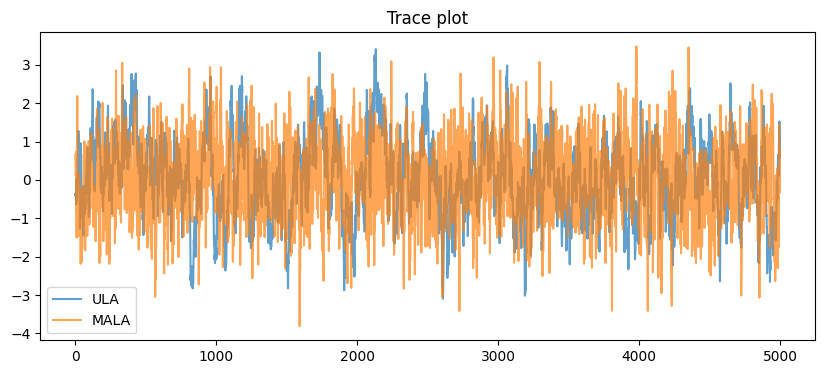

In [6]:
plt.figure(figsize=(10,4))

plt.plot(ula_samples, label="ULA", alpha=0.7)
plt.plot(mala_samples, label="MALA", alpha=0.7)

plt.legend()
plt.title("Trace plot")
plt.show()

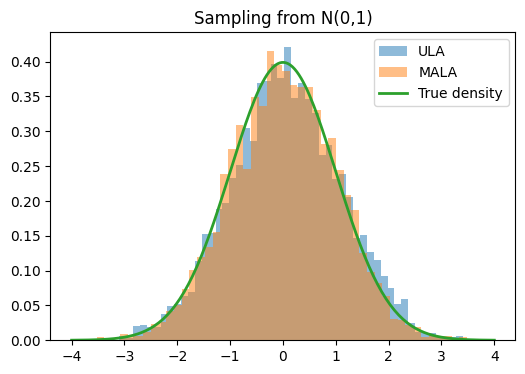

In [7]:
x = np.linspace(-4,4,200)
true_density = 1/np.sqrt(2*np.pi) * np.exp(-0.5*x**2)

plt.figure(figsize=(6,4))

plt.hist(ula_samples, bins=50, density=True, alpha=0.5, label="ULA")
plt.hist(mala_samples, bins=50, density=True, alpha=0.5, label="MALA")

plt.plot(x, true_density, label="True density", linewidth=2)

plt.legend()
plt.title("Sampling from N(0,1)")
plt.show()

In [8]:
print("ULA summary")
print(trace_summary(ula_samples))

print()

print("MALA summary")
print(trace_summary(mala_samples))

ULA summary
{'mean': np.float64(0.06484742886566373), 'variance': np.float64(1.093929917561068), 'n_samples': 5000}

MALA summary
{'mean': np.float64(0.016075419160880188), 'variance': np.float64(1.0057779446231132), 'n_samples': 5000}
